In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
import missingno as mso


In [134]:
df=pd.read_excel(r"D:\new\Downloads\online+retail\Online Retail.xlsx")

In [135]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [136]:
df.shape

(541909, 8)

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [138]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [139]:
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['hour'] = df['InvoiceDate'].dt.hour
df['minute'] = df['InvoiceDate'].dt.minute
df['second'] = df['InvoiceDate'].dt.second

In [140]:
df.drop('InvoiceDate', axis=1, inplace=True)

In [141]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [142]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,year,month,day,hour,minute,second,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,1,8,26,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,1,8,26,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34


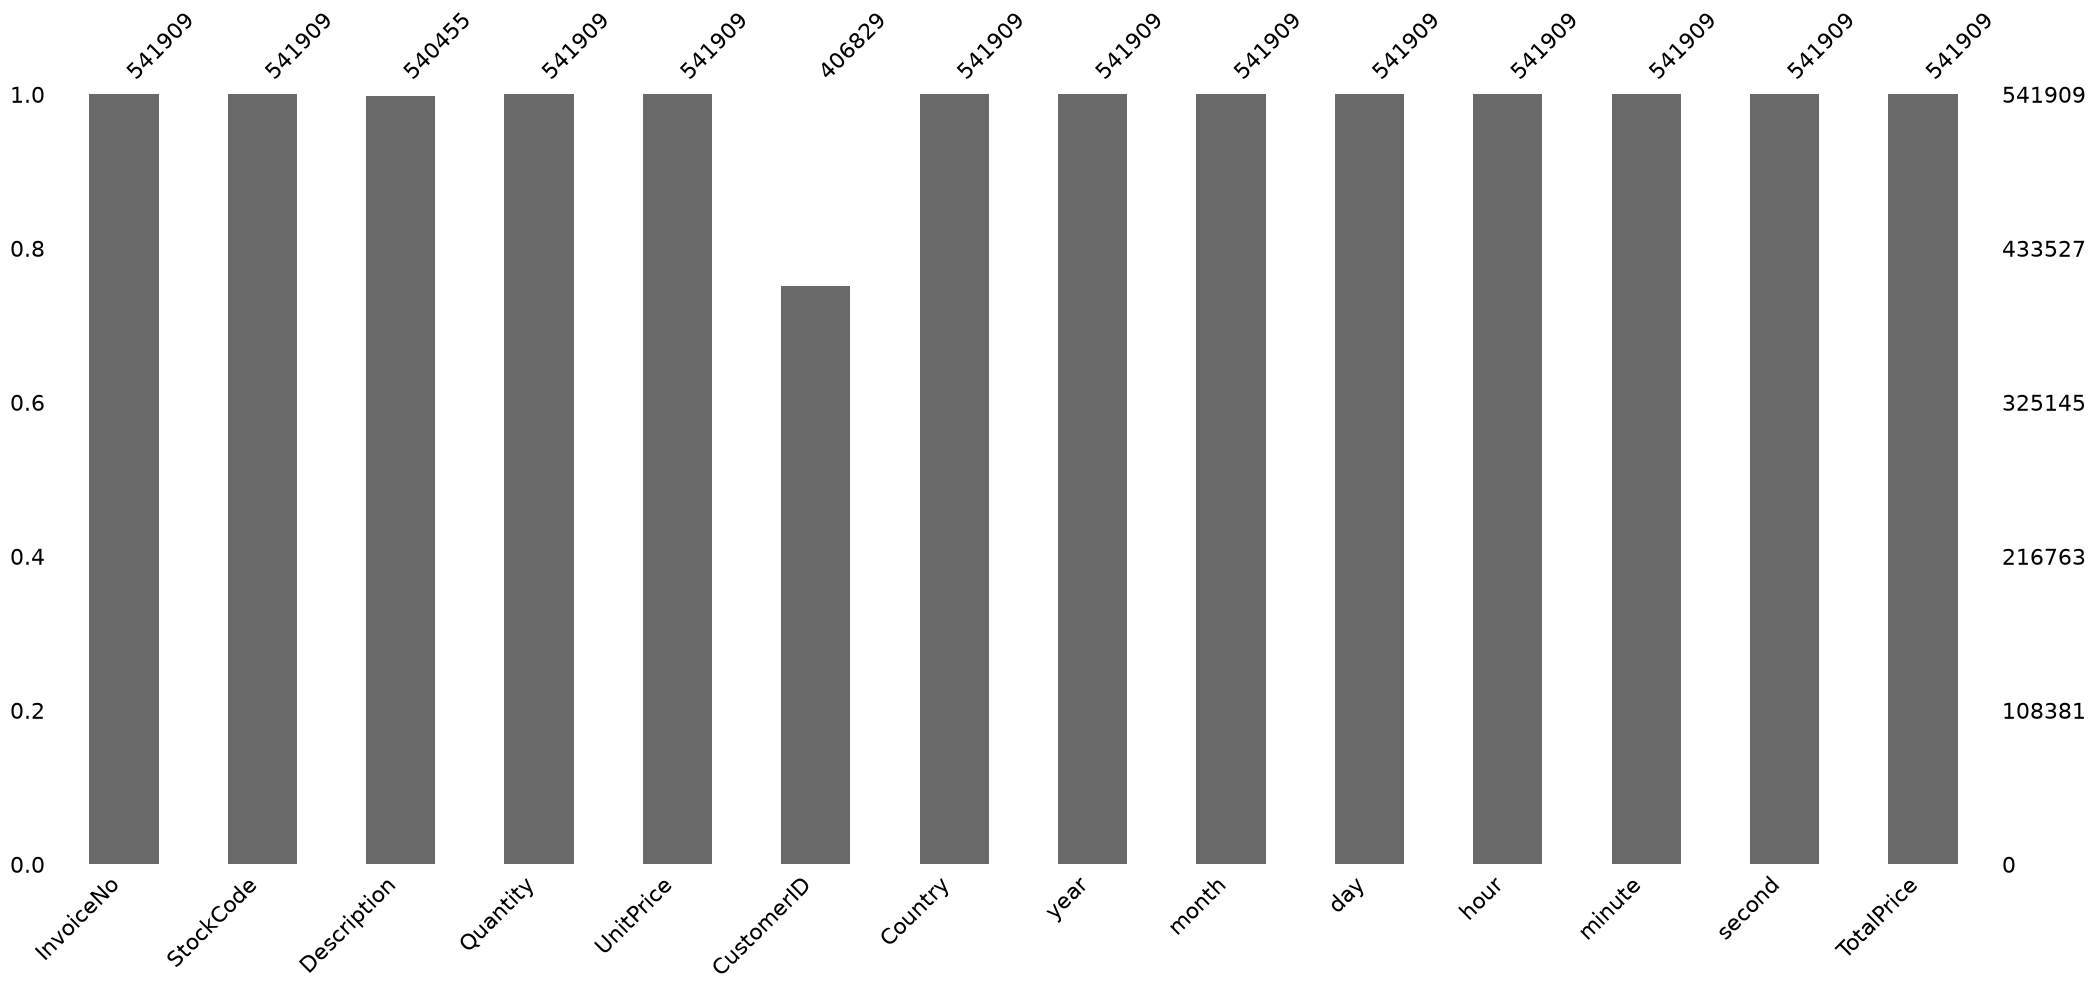

In [143]:
mso.bar(df)
plt.show()

In [144]:
df.dropna(inplace=True)

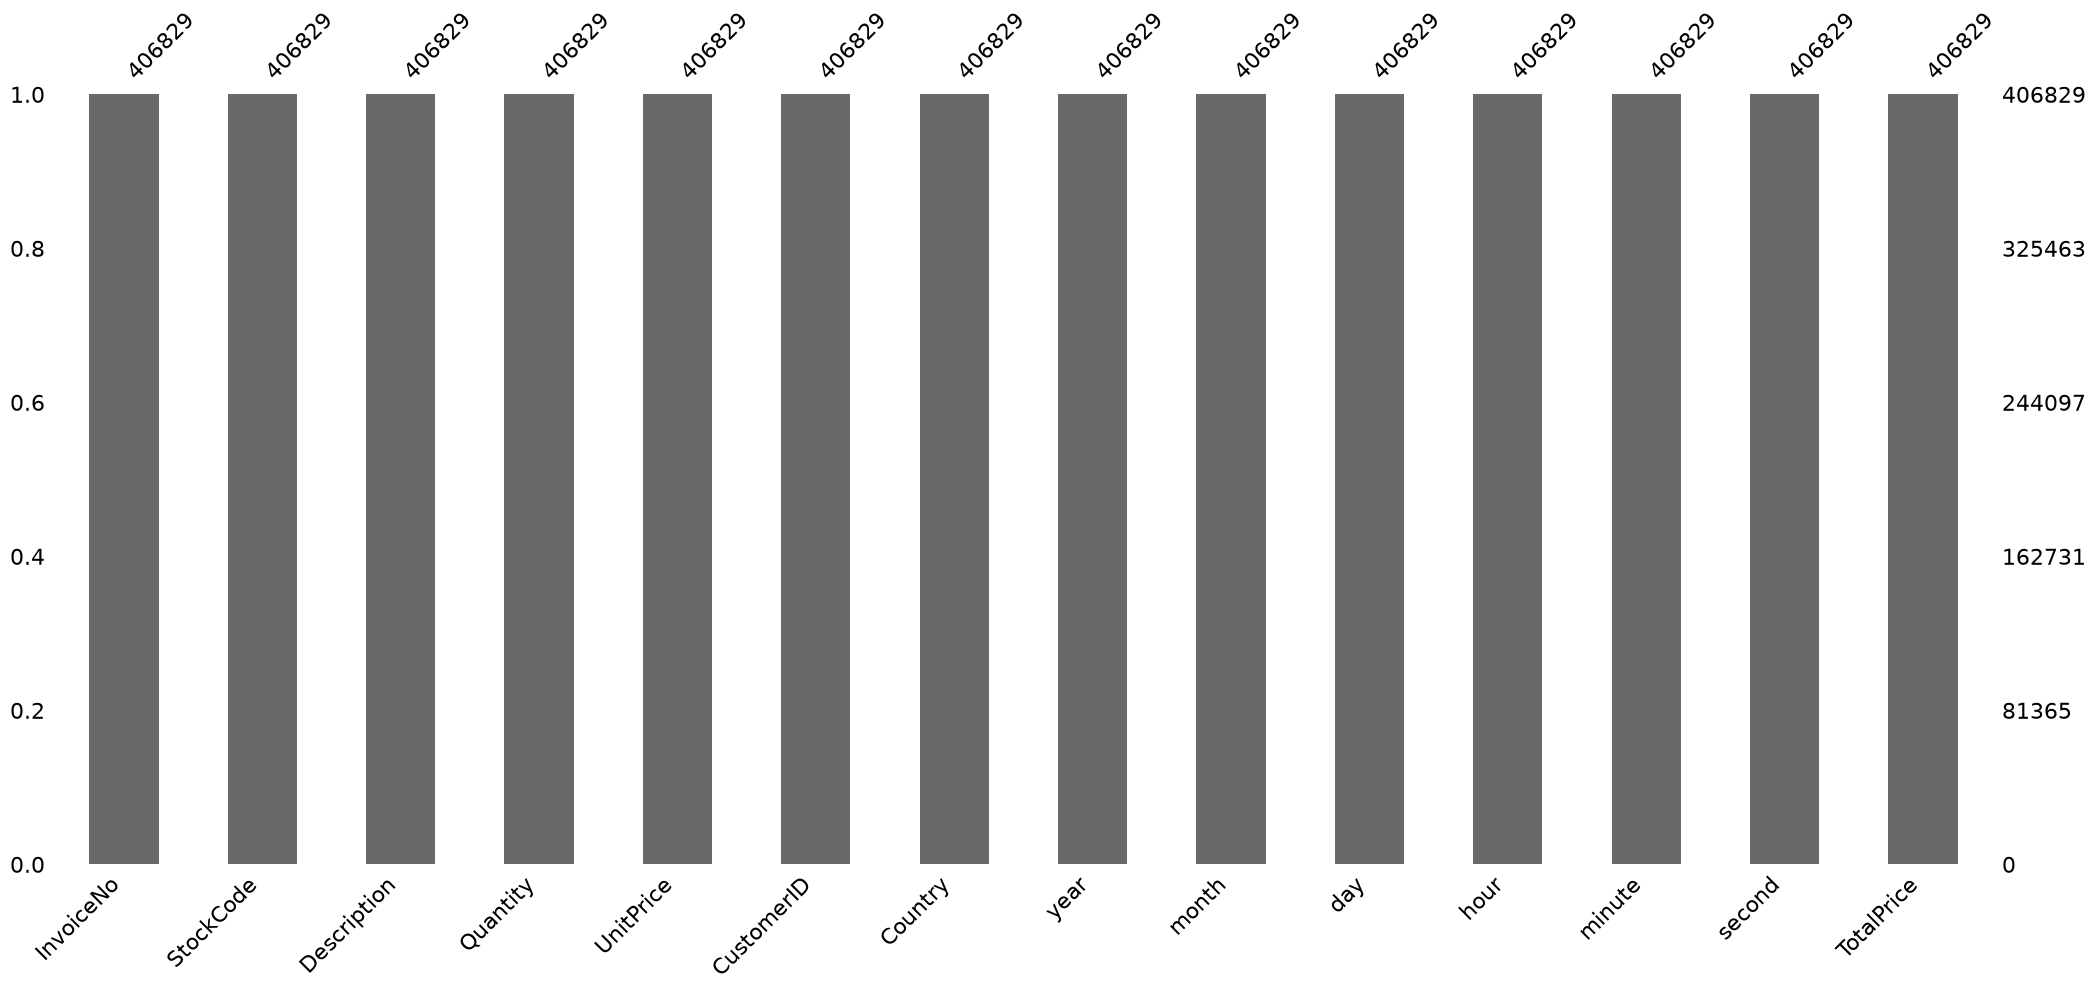

In [145]:
mso.bar(df)
plt.show()

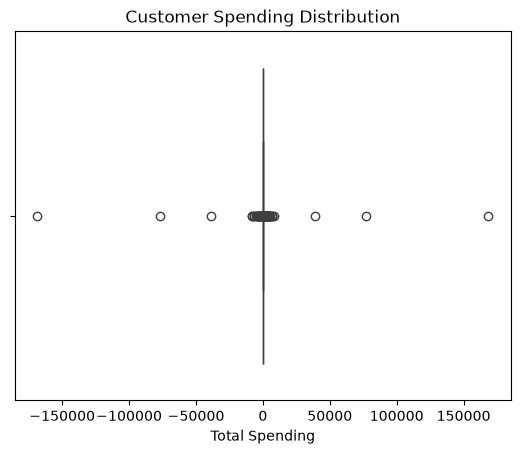

In [146]:
sns.boxplot(x=df['TotalPrice'])
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.show()

c:\Users\E_Magic\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\E_Magic\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


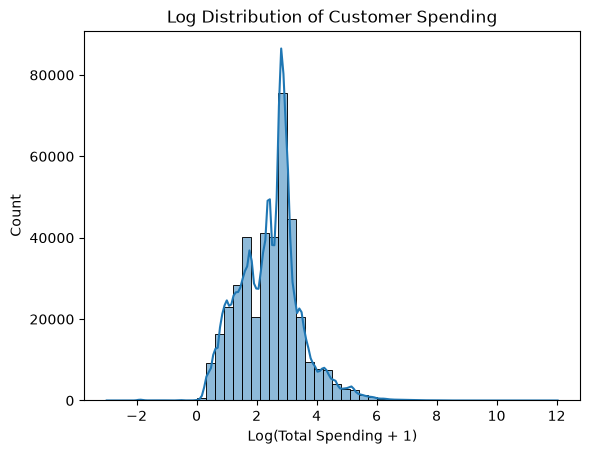

In [147]:
import numpy as np

sns.histplot(np.log1p(df['TotalPrice']),bins=50,kde=True)

plt.title('Log Distribution of Customer Spending')
plt.xlabel('Log(Total Spending + 1)')
plt.show()

In [148]:
threshold = df['TotalPrice'].quantile(0.75)
df['Target'] = (df['TotalPrice'] >= threshold).astype(int)

In [149]:
print(df['Target'].value_counts())

Target
0    303898
1    102931
Name: count, dtype: int64


In [150]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,year,month,day,hour,minute,second,TotalPrice,Target
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,1,8,26,0,15.30,0
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,1,8,26,0,22.00,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,0,20.34,1


In [151]:
df.drop(columns=['InvoiceNo', 'StockCode', 'Description', 'CustomerID','Country'], inplace=True)

In [152]:
df.head()

,Quantity,UnitPrice,year,month,day,hour,minute,second,TotalPrice,Target
0,6,2.55,2010,12,1,8,26,0,15.30,0
1,6,3.39,2010,12,1,8,26,0,20.34,1
2,8,2.75,2010,12,1,8,26,0,22.00,1
3,6,3.39,2010,12,1,8,26,0,20.34,1
4,6,3.39,2010,12,1,8,26,0,20.34,1


In [153]:
y=df['Target']


In [154]:
df.drop(columns=['Target'],inplace=True)

In [155]:
df

,Quantity,UnitPrice,year,month,day,hour,minute,second,TotalPrice
0,6,2.55,2010,12,1,8,26,0,15.30
1,6,3.39,2010,12,1,8,26,0,20.34
2,8,2.75,2010,12,1,8,26,0,22.00
3,6,3.39,2010,12,1,8,26,0,20.34
4,6,3.39,2010,12,1,8,26,0,20.34
...,...,...,...,...,...,...,...,...,...
541904,12,0.85,2011,12,9,12,50,0,10.20
541905,6,2.10,2011,12,9,12,50,0,12.60
541906,4,4.15,2011,12,9,12,50,0,16.60
541907,4,4.15,2011,12,9,12,50,0,16.60


In [156]:
from sklearn.model_selection import train_test_split


In [157]:
x_train,x_test,y_train, y_test=train_test_split(df, y , test_size=0.2,random_state=60)

In [158]:
from sklearn.preprocessing import StandardScaler

In [159]:
scaler=StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [160]:
from sklearn.linear_model import LogisticRegression

In [165]:
Heba3mara=LogisticRegression()
Heba3mara.fit(x_train, y_train)

c:\Users\E_Magic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [166]:
y_pred=Heba3mara.predict(x_test)

In [167]:
from sklearn.metrics import accuracy_score,classification_report
print("acc",accuracy_score(y_test,y_pred))
print("cla",classification_report(y_test,y_pred))

acc 0.999901678833911
cla               precision    recall  f1-score   support

           0       1.00      1.00      1.00     60868
           1       1.00      1.00      1.00     20498

    accuracy                           1.00     81366
   macro avg       1.00      1.00      1.00     81366
weighted avg       1.00      1.00      1.00     81366



In [168]:
df.head()

,Quantity,UnitPrice,year,month,day,hour,minute,second,TotalPrice
0,6,2.55,2010,12,1,8,26,0,15.30
1,6,3.39,2010,12,1,8,26,0,20.34
2,8,2.75,2010,12,1,8,26,0,22.00
3,6,3.39,2010,12,1,8,26,0,20.34
4,6,3.39,2010,12,1,8,26,0,20.34
